In [3]:
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.CIFAR100(
    root="./data",
    train=True,
    download=True,   # ← Ye automatically download karega
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR100(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print(len(train_dataset), len(test_dataset))

Files already downloaded and verified
Files already downloaded and verified
50000 10000


In [4]:
type(train_dataset)

torchvision.datasets.cifar.CIFAR100

In [5]:
print(train_dataset)

Dataset CIFAR100
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           )


In [6]:
img, label = train_dataset[0]

print(type(img))
print(type(label))

<class 'torch.Tensor'>
<class 'int'>


In [7]:
import numpy as np

x_train_list = []
y_train_list =[]

x_test_list =[]
y_test_list = []

for img,label in train_dataset:
    img = img.numpy()
    x_train_list.append(img)
    y_train_list.append(label)

for img,label in test_dataset:
    img = img.numpy()
    x_test_list.append(img)
    y_test_list.append(label)

x_train = np.array(x_train_list)
y_train = np.array(y_train_list)

x_test = np.array(x_test_list)
y_test = np.array(y_test_list)

x_train = np.transpose(x_train, (0, 2, 3, 1))
x_test  = np.transpose(x_test, (0, 2, 3, 1))

print(x_train.shape)
print(y_train.shape)


(50000, 32, 32, 3)
(50000,)


In [8]:
x_train.min(),x_train.max()

(0.0, 1.0)

In [9]:
mean = x_train.mean()
std = x_train.std()

print(mean,std)

0.47818068 0.2681919


In [10]:
x_train = (x_train - mean)/std
x_test = (x_test - mean)/std

In [11]:
mean = x_train.mean()
std = x_train.std()

print(mean,std)

-1.4567057e-07 1.0000006


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7829795..1.9456939].


(-0.5, 31.5, 31.5, -0.5)

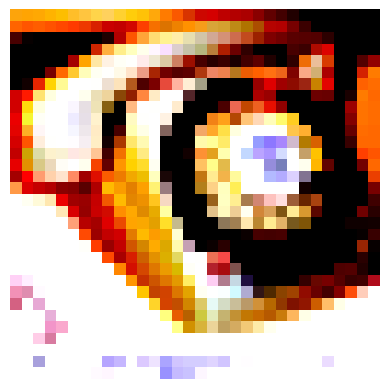

In [12]:
import matplotlib.pyplot as plt
plt.imshow(x_train[5])
plt.axis("off")

In [13]:
import torch 
from torch.utils.data import TensorDataset

x_train_t = torch.from_numpy(x_train).float()
y_train_t = torch.from_numpy(y_train).long()

x_test_t = torch.from_numpy(x_test).float()
y_test_t = torch.from_numpy(y_test).long()

train_dataset = TensorDataset(x_train_t,y_train_t)
test_dataset = TensorDataset(x_test_t,y_test_t)


In [14]:
from torch.utils.data import DataLoader

batch_size =16

train_loader = DataLoader(train_dataset,batch_size = batch_size ,shuffle = True)
test_loader = DataLoader(test_dataset,batch_size = batch_size , shuffle =False)

In [15]:
num_classes = len(np.unique(y_train))
print(num_classes)

100


In [33]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self,num_classes=num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # (N,32,112,112)

            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # (N,32,112,112)

            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 512, 3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),



        )
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.classification = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes),
            
        )
    def forward(self,x):
        x=self.features(x)
        x=self.pool(x)
        x=self.classification(x)
        return x
           
model = CNN()

In [34]:
import torch.optim as optim

certerian = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=4e-3, weight_decay=1e-2)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.3, patience=2, min_lr=1e-6)


In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Using:", device)

Using: cuda


In [36]:
def train_one_epoch(model,loader):
    model.train()
    total_loss,correct,total=0.0 , 0,0
    for x,y in loader:
      x,y = x.to(device),y.to(device)
             # NHWC -> NCHW
      if x.ndim == 4 and x.shape[-1] == 3:
            x = x.permute(0, 3, 1, 2).contiguous()
      optimizer.zero_grad()
      logits = model(x)
      loss = certerian(logits,y)
      loss.backward()
      optimizer.step()
        
      total_loss += loss.item()* x.size(0)
      pred = logits.argmax(dim=1)
      correct += (pred == y).sum().item()
      total+=y.size(0)
    return total_loss/total,correct/total
        
@torch.no_grad()
def evaluation_one_epoch(model ,loader):
    model.eval()
    total_loss,correct,total=0.0 , 0,0
    for x,y in loader:
        x,y=x.to(device),y.to(device)
               # NHWC -> NCHW
        if x.ndim == 4 and x.shape[-1] == 3:
            x = x.permute(0, 3, 1, 2).contiguous()
            
        logits = model(x)
        loss = certerian(logits,y)
        
        total_loss += loss.item()* x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return total_loss/total,correct/total
    

    

In [37]:
import torch
train_loss,test_loss =[],[]
train_acc,test_acc =[],[]
best_acc=0

epochs =20 
for epoch in range(1,epochs+1):
   tr_loss,tr_acc = train_one_epoch (model,train_loader)
   te_loss,te_acc = evaluation_one_epoch(model,test_loader)

   scheduler.step(float(te_loss))
    
   train_loss.append(tr_loss)
   train_acc.append(tr_acc)
   test_loss.append(te_loss)
   test_acc.append(te_acc)
   print(
        f"Epoch {epoch:02d} | Train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
        f"Test loss {te_loss:.4f} acc {te_acc:.4f}")
   if(te_acc>best_acc):
       best_acc = te_acc
       torch.save(model.state_dict(), "best_model.pth")
       print("Best model saved")
   
   

Epoch 01 | Train loss 4.0883 acc 0.0903 | Test loss 3.5955 acc 0.1896
Best model saved
Epoch 02 | Train loss 3.4424 acc 0.2247 | Test loss 3.1446 acc 0.3036
Best model saved
Epoch 03 | Train loss 3.0723 acc 0.3178 | Test loss 2.8307 acc 0.3885
Best model saved
Epoch 04 | Train loss 2.8372 acc 0.3828 | Test loss 2.6414 acc 0.4394
Best model saved
Epoch 05 | Train loss 2.5064 acc 0.4824 | Test loss 2.3742 acc 0.5238
Best model saved
Epoch 06 | Train loss 2.3962 acc 0.5150 | Test loss 2.3237 acc 0.5390
Best model saved
Epoch 07 | Train loss 2.3189 acc 0.5391 | Test loss 2.3057 acc 0.5407
Best model saved
Epoch 08 | Train loss 2.1770 acc 0.5853 | Test loss 2.2382 acc 0.5650
Best model saved
Epoch 09 | Train loss 2.1374 acc 0.5976 | Test loss 2.2170 acc 0.5698
Best model saved
Epoch 10 | Train loss 2.1077 acc 0.6075 | Test loss 2.2154 acc 0.5725
Best model saved
Epoch 11 | Train loss 2.0540 acc 0.6272 | Test loss 2.1978 acc 0.5765
Best model saved
Epoch 12 | Train loss 2.0428 acc 0.6324 | T

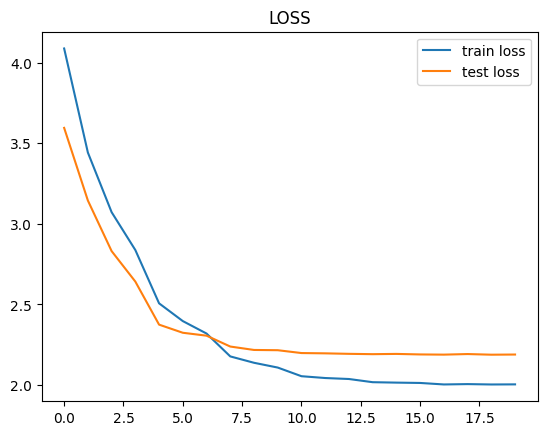

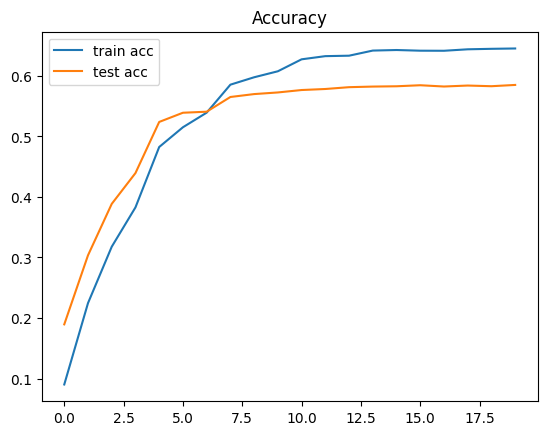

In [38]:
import matplotlib.pyplot as plt
plt.figure
plt.plot(train_loss, label = "train loss")
plt.plot(test_loss, label = "test loss")
plt.legend()
plt.title("LOSS")
plt.show()

plt.figure
plt.plot(train_acc, label = "train acc")
plt.plot(test_acc, label = "test acc")
plt.legend()
plt.title("Accuracy")
plt.show()